<a href="https://colab.research.google.com/github/houssamak/deeplearning/blob/CNN/Partie_2_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importation des bibliothèques

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {device}')
if device.type == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')

Device utilisé : cuda
GPU : Tesla T4


Calculs manuels de dimensions (section théorique illustrée)

In [6]:
def compute_conv_output_size(w_in, kernel, padding, stride):
    """Calcule la taille de sortie d'une couche de convolution."""
    return (w_in - kernel + 2 * padding) // stride + 1

def compute_pool_output_size(w_in, kernel, stride):
    """Calcule la taille de sortie d'une couche de pooling."""
    return (w_in - kernel) // stride + 1

print("=" * 60)
print("CALCULS DIMENSIONNELS – Architecture LeNet sur CIFAR-10")
print("=" * 60)
print(f"Image d'entrée : 32 × 32 × 3")

# Conv1 : kernel=5, padding=2, stride=1, filtres=6
s1 = compute_conv_output_size(32, 5, 2, 1)
print(f"\nConv1 (K=5, P=2, S=1) → {s1} × {s1} × 6")

# Pool1 : kernel=2, stride=2
p1 = compute_pool_output_size(s1, 2, 2)
print(f"Pool1 (K=2, S=2)      → {p1} × {p1} × 6")

# Conv2 : kernel=5, padding=0, stride=1, filtres=16
s2 = compute_conv_output_size(p1, 5, 0, 1)
print(f"Conv2 (K=5, P=0, S=1) → {s2} × {s2} × 16")

# Pool2 : kernel=2, stride=2
p2 = compute_pool_output_size(s2, 2, 2)
print(f"Pool2 (K=2, S=2)      → {p2} × {p2} × 16")

flatten = p2 * p2 * 16
print(f"Flatten               → {flatten} neurones")
print(f"FC1 (120), FC2 (84), FC3 (10)")

print("\n" + "-" * 60)
print("Exemples divers de calculs de sortie :")
print("-" * 60)
configs = [
    (28, 3, 1, 1, "K=3 P=1 S=1 (same)"),
    (28, 3, 0, 1, "K=3 P=0 S=1 (valid)"),
    (28, 3, 0, 2, "K=3 P=0 S=2 (stride 2)"),
    (32, 5, 2, 1, "K=5 P=2 S=1 (same)"),
]
for (w, k, p, s, label) in configs:
    out = compute_conv_output_size(w, k, p, s)
    print(f"  Entrée {w}×{w}, {label} → {out}×{out}")

CALCULS DIMENSIONNELS – Architecture LeNet sur CIFAR-10
Image d'entrée : 32 × 32 × 3

Conv1 (K=5, P=2, S=1) → 32 × 32 × 6
Pool1 (K=2, S=2)      → 16 × 16 × 6
Conv2 (K=5, P=0, S=1) → 12 × 12 × 16
Pool2 (K=2, S=2)      → 6 × 6 × 16
Flatten               → 576 neurones
FC1 (120), FC2 (84), FC3 (10)

------------------------------------------------------------
Exemples divers de calculs de sortie :
------------------------------------------------------------
  Entrée 28×28, K=3 P=1 S=1 (same) → 28×28
  Entrée 28×28, K=3 P=0 S=1 (valid) → 26×26
  Entrée 28×28, K=3 P=0 S=2 (stride 2) → 13×13
  Entrée 32×32, K=5 P=2 S=1 (same) → 32×32



2. Implémentation manuelle des opérations convolutionnelles :
2.1 Corrélation croisée 2D

In [8]:
def cross_correlation_2d_manual(X, K):
    """
    Corrélation croisée 2D (opération de base d'une conv sans padding).
    X : tableau 2D (H, W)
    K : noyau 2D (kH, kW)
    Retourne : carte de sortie 2D
    """
    h, w = X.shape
    kh, kw = K.shape
    out_h = h - kh + 1
    out_w = w - kw + 1
    Y = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            Y[i, j] = np.sum(X[i:i+kh, j:j+kw] * K)
    return Y


def max_pooling_2d_manual(X, pool_size=2, stride=2):
    """
    Max pooling 2D manuel.
    """
    h, w = X.shape
    out_h = (h - pool_size) // stride + 1
    out_w = (w - pool_size) // stride + 1
    Y = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            Y[i, j] = np.max(X[i*stride:i*stride+pool_size,
                                j*stride:j*stride+pool_size])
    return Y


def avg_pooling_2d_manual(X, pool_size=2, stride=2):
    """
    Average pooling 2D manuel.
    """
    h, w = X.shape
    out_h = (h - pool_size) // stride + 1
    out_w = (w - pool_size) // stride + 1
    Y = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            Y[i, j] = np.mean(X[i*stride:i*stride+pool_size,
                                 j*stride:j*stride+pool_size])
    return Y


# --- Test numérique ---
X_test = np.array([[1, 2, 3, 4],
                   [5, 6, 7, 8],
                   [9,10,11,12],
                   [13,14,15,16]], dtype=float)

K_edge = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]], dtype=float)  # Filtre de détection de bords

K_blur = np.ones((3,3)) / 9.0  # Filtre de flou moyen

Y_edge = cross_correlation_2d_manual(X_test, K_edge)
Y_blur = cross_correlation_2d_manual(X_test, K_blur)
Y_maxp = max_pooling_2d_manual(X_test, 2, 2)
Y_avgp = avg_pooling_2d_manual(X_test, 2, 2)

print("Matrice d'entrée X :")
print(X_test)
print("\nRésultat corrélation croisée (filtre bord) :")
print(Y_edge)
print("\nRésultat corrélation croisée (flou moyen) :")
print(Y_blur)
print("\nMax pooling (2×2, stride 2) :")
print(Y_maxp)
print("\nAverage pooling (2×2, stride 2) :")
print(Y_avgp)

Matrice d'entrée X :
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]

Résultat corrélation croisée (filtre bord) :
[[0. 0.]
 [0. 0.]]

Résultat corrélation croisée (flou moyen) :
[[ 6.  7.]
 [10. 11.]]

Max pooling (2×2, stride 2) :
[[ 6.  8.]
 [14. 16.]]

Average pooling (2×2, stride 2) :
[[ 3.5  5.5]
 [11.5 13.5]]


Comparaison implémentation manuelle vs PyTorch : Corrélation croisée avec PyTorch



In [9]:
X_torch = torch.tensor(X_test, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,4,4)
K_torch = torch.tensor(K_edge, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # (1,1,3,3)

Y_torch_conv = F.conv2d(X_torch, K_torch, padding=0)
Y_torch_maxp = F.max_pool2d(X_torch, kernel_size=2, stride=2)
Y_torch_avgp = F.avg_pool2d(X_torch, kernel_size=2, stride=2)

print("Comparaison Manuel vs PyTorch")
print("=" * 50)
print("Corrélation croisée (bord):")
print(f"  Manuel   : {Y_edge}")
print(f"  PyTorch  : {Y_torch_conv.squeeze().numpy()}")
print(f"  Différence max : {np.max(np.abs(Y_edge - Y_torch_conv.squeeze().numpy())):.2e}")

print("\nMax pooling :")
print(f"  Manuel   : {Y_maxp}")
print(f"  PyTorch  : {Y_torch_maxp.squeeze().numpy()}")
print(f"  Différence max : {np.max(np.abs(Y_maxp - Y_torch_maxp.squeeze().numpy())):.2e}")

print("\nAverage pooling :")
print(f"  Manuel   : {Y_avgp}")
print(f"  PyTorch  : {Y_torch_avgp.squeeze().numpy()}")
print(f"  Différence max : {np.max(np.abs(Y_avgp - Y_torch_avgp.squeeze().numpy())):.2e}")

Comparaison Manuel vs PyTorch
Corrélation croisée (bord):
  Manuel   : [[0. 0.]
 [0. 0.]]
  PyTorch  : [[0. 0.]
 [0. 0.]]
  Différence max : 0.00e+00

Max pooling :
  Manuel   : [[ 6.  8.]
 [14. 16.]]
  PyTorch  : [[ 6.  8.]
 [14. 16.]]
  Différence max : 0.00e+00

Average pooling :
  Manuel   : [[ 3.5  5.5]
 [11.5 13.5]]
  PyTorch  : [[ 3.5  5.5]
 [11.5 13.5]]
  Différence max : 0.00e+00


Préparation du dataset CIFAR-10 :  Normalisation standard CIFAR-10 (moyenne et std par canal RGB)

In [10]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# Téléchargement
full_train = torchvision.datasets.CIFAR10(root='./data', train=True,
                                           download=True, transform=transform_train)
test_set   = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform_test)

# Séparation train / validation (80 / 20)
n_train = int(0.8 * len(full_train))
n_val   = len(full_train) - n_train
train_set, val_set = random_split(full_train, [n_train, n_val],
                                  generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

CLASSES = ['avion','automobile','oiseau','chat','cerf',
           'chien','grenouille','cheval','bateau','camion']

print(f"Taille train      : {len(train_set)}")
print(f"Taille validation : {len(val_set)}")
print(f"Taille test       : {len(test_set)}")
print(f"Classes : {CLASSES}")

100%|██████████| 170M/170M [00:17<00:00, 9.66MB/s]


Taille train      : 40000
Taille validation : 10000
Taille test       : 10000
Classes : ['avion', 'automobile', 'oiseau', 'chat', 'cerf', 'chien', 'grenouille', 'cheval', 'bateau', 'camion']


Visualisation de quelques images

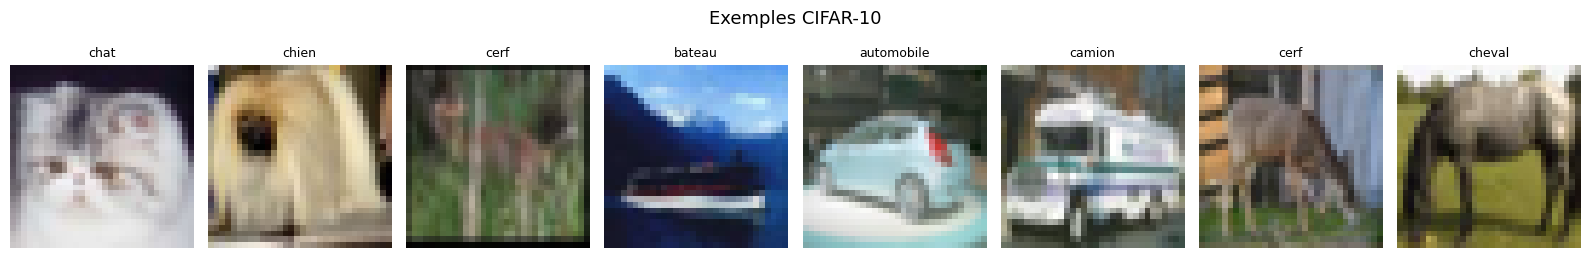

In [11]:
def imshow_grid(dataset, n=8):
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.5))
    indices = np.random.choice(len(dataset), n, replace=False)
    for ax, idx in zip(axes, indices):
        img, label = dataset[idx]
        # Dénormalisation pour affichage
        mean = torch.tensor(CIFAR_MEAN).view(3,1,1)
        std  = torch.tensor(CIFAR_STD).view(3,1,1)
        img = img * std + mean
        img = img.permute(1, 2, 0).numpy().clip(0, 1)
        ax.imshow(img)
        ax.set_title(CLASSES[label], fontsize=9)
        ax.axis('off')
    plt.suptitle('Exemples CIFAR-10', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('cifar10_exemples.png', bbox_inches='tight', dpi=120)
    plt.show()

imshow_grid(test_set)

 MLP de référence (pour comparaison avec CNN)


In [12]:
class MLP_Image(nn.Module):
    """MLP appliqué directement aux pixels aplatis."""
    def __init__(self, input_size=3*32*32, num_classes=10):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

mlp_model = MLP_Image().to(device)
n_params_mlp = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"Nombre de paramètres MLP : {n_params_mlp:,}")
print(mlp_model)

Nombre de paramètres MLP : 1,738,890
MLP_Image(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)


5. Implémentation du CNN inspiré de LeNet (version améliorée) :  CNN inspiré de LeNet – Version de base

In [13]:
class LeNet_Base(nn.Module):
    """
    Architecture inspirée de LeNet adaptée à CIFAR-10 (32×32 RGB).
    Conv1 → Pool → Conv2 → Pool → FC1 → FC2 → FC3
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # Bloc convolutionnel 1
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6,
                               kernel_size=5, padding=2)  # 32×32 → 32×32
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)  # 32×32 → 16×16

        # Bloc convolutionnel 2
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16,
                               kernel_size=5, padding=0)  # 16×16 → 12×12
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)  # 12×12 → 6×6

        # Couches fully connected
        self.fc1 = nn.Linear(16 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = torch.tanh(self.conv1(x))
        x = self.pool1(x)
        x = torch.tanh(self.conv2(x))
        x = self.pool2(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = self.fc3(x)
        return x

lenet = LeNet_Base().to(device)
n_params_lenet = sum(p.numel() for p in lenet.parameters() if p.requires_grad)
print(f"Nombre de paramètres LeNet base : {n_params_lenet:,}")
print(lenet)

Nombre de paramètres LeNet base : 83,126
LeNet_Base(
  (conv1): Conv2d(3, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


CNN amélioré avec BatchNorm, ReLU, MaxPool et conv 1×1

In [14]:
class CNN_Improved(nn.Module):
    """
    CNN amélioré avec :
    - BatchNorm pour stabiliser l'entraînement
    - ReLU à la place de Tanh
    - MaxPooling (plus agressif que AvgPool)
    - Convolution 1×1 pour réduction de dimensionnalité
    - Dropout pour régularisation
    """
    def __init__(self, num_classes=10, use_conv1x1=True):
        super().__init__()
        self.use_conv1x1 = use_conv1x1

        # Bloc 1 : 3 → 32 filtres
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 32×32 → 16×16
            nn.Dropout2d(0.25)
        )

        # Convolution 1×1 optionnelle (réduction de canaux)
        self.conv1x1 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=1),
            nn.ReLU()
        ) if use_conv1x1 else nn.Identity()
        channels_after_1x1 = 16 if use_conv1x1 else 32

        # Bloc 2 : → 64 filtres
        self.block2 = nn.Sequential(
            nn.Conv2d(channels_after_1x1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),  # 16×16 → 8×8
            nn.Dropout2d(0.25)
        )

        # Classificateur
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.conv1x1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

cnn_improved = CNN_Improved(use_conv1x1=True).to(device)
n_params_cnn = sum(p.numel() for p in cnn_improved.parameters() if p.requires_grad)
print(f"Nombre de paramètres CNN amélioré : {n_params_cnn:,}")
print(cnn_improved)

Nombre de paramètres CNN amélioré : 2,160,058
CNN_Improved(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv1x1): Sequential(
    (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
  )
  (block2): Sequential(
    (0): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum

Fonctions d'entraînement et d'évaluation

In [15]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += X.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            total_loss += loss.item() * X.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += X.size(0)
    return total_loss / total, correct / total


def train_model(model, train_loader, val_loader, n_epochs=20, lr=1e-3,
                model_name='model', scheduler_type='cosine'):
    """
    Entraîne un modèle et retourne l'historique des métriques.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    if scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    else:
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state = None
    t0 = time.time()

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            torch.save(best_state, f'best_{model_name}.pth')

        if epoch % 5 == 0 or epoch == 1:
            print(f"Epoch {epoch:3d}/{n_epochs} | "
                  f"Train loss={tr_loss:.4f} acc={tr_acc:.4f} | "
                  f"Val loss={vl_loss:.4f} acc={vl_acc:.4f}")

    elapsed = time.time() - t0
    print(f"\nEntraînement terminé en {elapsed:.1f}s | Meilleure val acc = {best_val_acc:.4f}")
    model.load_state_dict(best_state)  # Recharge le meilleur modèle
    return history


def plot_history(history, title='Courbes d\'entraînement'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_loss']) + 1)

    ax1.plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
    ax1.plot(epochs, history['val_loss'],   'r-o', ms=3, label='Validation')
    ax1.set_title(f'{title} – Loss')
    ax1.set_xlabel('Époque')
    ax1.set_ylabel('Cross-Entropy Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, [a*100 for a in history['train_acc']], 'b-o', ms=3, label='Train')
    ax2.plot(epochs, [a*100 for a in history['val_acc']],   'r-o', ms=3, label='Validation')
    ax2.set_title(f'{title} – Accuracy')
    ax2.set_xlabel('Époque')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}_curves.png', dpi=120)
    plt.show()

Entraînement MLP


ENTRAÎNEMENT MLP (référence)
Epoch   1/20 | Train loss=1.9258 acc=0.2970 | Val loss=1.7786 acc=0.3536
Epoch   5/20 | Train loss=1.6770 acc=0.3982 | Val loss=1.6069 acc=0.4272
Epoch  10/20 | Train loss=1.5669 acc=0.4377 | Val loss=1.4979 acc=0.4710
Epoch  15/20 | Train loss=1.4771 acc=0.4697 | Val loss=1.4144 acc=0.4938
Epoch  20/20 | Train loss=1.4366 acc=0.4835 | Val loss=1.3771 acc=0.5036

Entraînement terminé en 340.1s | Meilleure val acc = 0.5123


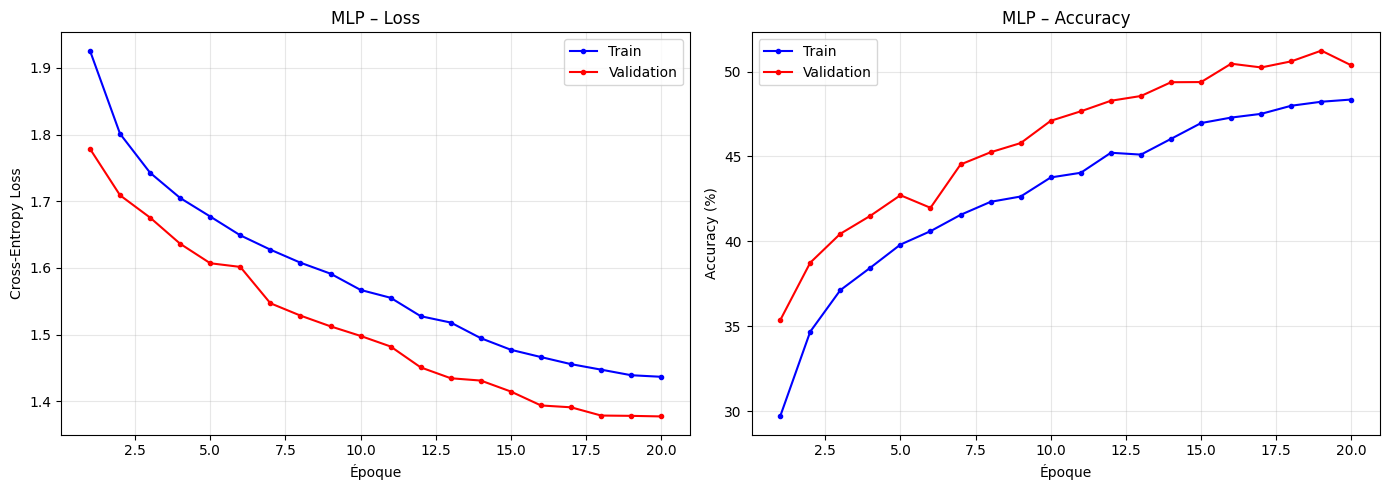

In [16]:
print("=" * 60)
print("ENTRAÎNEMENT MLP (référence)")
print("=" * 60)
mlp_model = MLP_Image().to(device)
history_mlp = train_model(mlp_model, train_loader, val_loader,
                           n_epochs=20, lr=1e-3, model_name='mlp')
plot_history(history_mlp, 'MLP')

Entraînement CNN amélioré

ENTRAÎNEMENT CNN AMÉLIORÉ
Epoch   1/25 | Train loss=1.9306 acc=0.2923 | Val loss=1.6112 acc=0.4077
Epoch   5/25 | Train loss=1.3825 acc=0.4975 | Val loss=1.1582 acc=0.5853
Epoch  10/25 | Train loss=1.1676 acc=0.5810 | Val loss=0.9565 acc=0.6532
Epoch  15/25 | Train loss=1.0482 acc=0.6284 | Val loss=0.8703 acc=0.6915
Epoch  20/25 | Train loss=0.9769 acc=0.6579 | Val loss=0.8179 acc=0.7046
Epoch  25/25 | Train loss=0.9481 acc=0.6650 | Val loss=0.7854 acc=0.7220

Entraînement terminé en 465.1s | Meilleure val acc = 0.7220


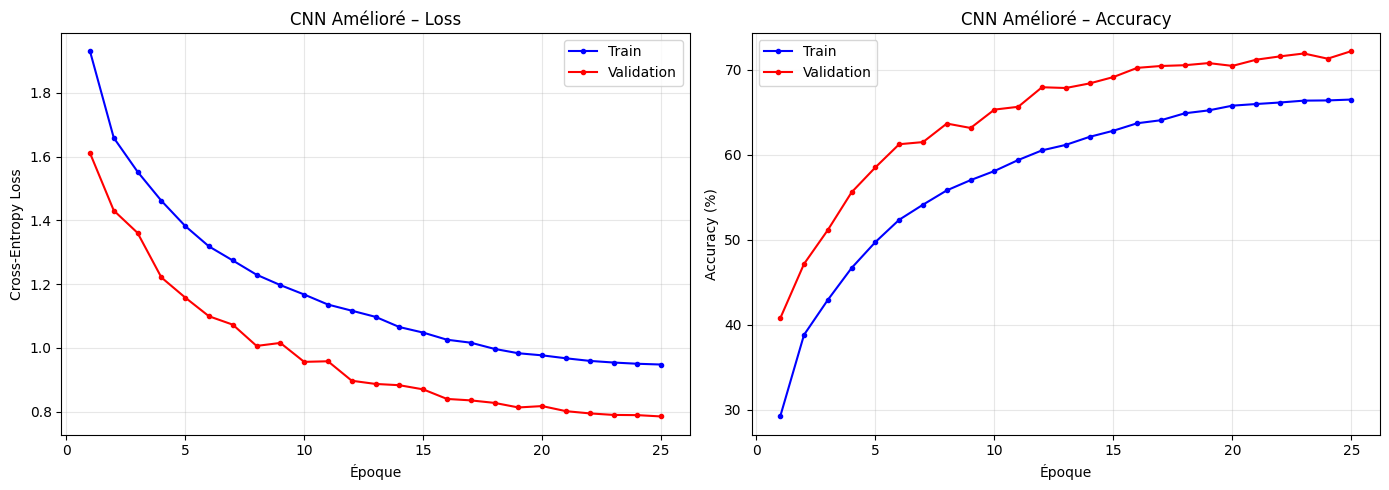

In [17]:
print("=" * 60)
print("ENTRAÎNEMENT CNN AMÉLIORÉ")
print("=" * 60)
cnn_improved = CNN_Improved(use_conv1x1=True).to(device)
history_cnn = train_model(cnn_improved, train_loader, val_loader,
                           n_epochs=25, lr=1e-3, model_name='cnn_improved')
plot_history(history_cnn, 'CNN Amélioré')

Étude expérimentale – Variantes architecturales: :Chaque variante modifie UN seul hyperparamètre

In [18]:
class CNN_Variant(nn.Module):
    """
    CNN flexible pour tester différentes configurations.
    Paramètres :
      pool_type  : 'max' ou 'avg'
      padding    : 0 ou 1 pour les convolutions
      stride     : 1 ou 2 pour les convolutions
      n_filters  : nombre de filtres dans le premier bloc (32, 64, 128)
      use_conv1x1: True ou False
    """
    def __init__(self, pool_type='max', padding=1, stride=1,
                 n_filters=32, use_conv1x1=False, num_classes=10):
        super().__init__()
        Pool = nn.MaxPool2d if pool_type == 'max' else nn.AvgPool2d

        self.features = nn.Sequential(
            nn.Conv2d(3, n_filters, kernel_size=3, padding=padding, stride=stride),
            nn.BatchNorm2d(n_filters), nn.ReLU(),
            Pool(2, 2),
            nn.Conv2d(n_filters, n_filters*2, kernel_size=3, padding=padding, stride=1),
            nn.BatchNorm2d(n_filters*2), nn.ReLU(),
            Pool(2, 2),
        )

        # Calcul dynamique de la taille après feature extraction
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 32, 32)
            out = self.features(dummy)
            flat_size = out.view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# Configurations à tester
experiments = [
    {'name': 'Référence (MaxPool, P=1, S=1, 32f)',
     'pool_type': 'max', 'padding': 1, 'stride': 1, 'n_filters': 32},
    {'name': 'AvgPool',
     'pool_type': 'avg', 'padding': 1, 'stride': 1, 'n_filters': 32},
    {'name': 'Padding=0 (valid)',
     'pool_type': 'max', 'padding': 0, 'stride': 1, 'n_filters': 32},
    {'name': 'Stride=2 (conv)',
     'pool_type': 'max', 'padding': 1, 'stride': 2, 'n_filters': 32},
    {'name': '64 filtres',
     'pool_type': 'max', 'padding': 1, 'stride': 1, 'n_filters': 64},
    {'name': '16 filtres',
     'pool_type': 'max', 'padding': 1, 'stride': 1, 'n_filters': 16},
]

N_EPOCHS_EXP = 15  # Réduit pour accélérer l'expérimentation
results_exp = []

criterion = nn.CrossEntropyLoss()

for exp in experiments:
    print(f"\n{'='*55}")
    print(f"CONFIG : {exp['name']}")
    print('='*55)
    try:
        model_v = CNN_Variant(
            pool_type=exp['pool_type'],
            padding=exp['padding'],
            stride=exp['stride'],
            n_filters=exp['n_filters']
        ).to(device)
        n_params = sum(p.numel() for p in model_v.parameters() if p.requires_grad)
        optimizer_v = optim.Adam(model_v.parameters(), lr=1e-3, weight_decay=1e-4)
        scheduler_v = optim.lr_scheduler.CosineAnnealingLR(optimizer_v, T_max=N_EPOCHS_EXP)
        best_val = 0.0
        t0 = time.time()
        for ep in range(N_EPOCHS_EXP):
            train_epoch(model_v, train_loader, optimizer_v, criterion)
            _, vl_acc = evaluate(model_v, val_loader, criterion)
            scheduler_v.step()
            if vl_acc > best_val:
                best_val = vl_acc
        elapsed = time.time() - t0
        # Test final
        _, test_acc = evaluate(model_v, test_loader, criterion)
        results_exp.append({
            'Config': exp['name'],
            'Params': n_params,
            'Best Val Acc': round(best_val * 100, 2),
            'Test Acc': round(test_acc * 100, 2),
            'Temps (s)': round(elapsed, 1)
        })
        print(f"  → Params={n_params:,} | Val={best_val*100:.2f}% | Test={test_acc*100:.2f}% | {elapsed:.0f}s")
    except Exception as e:
        print(f"  ✗ Erreur : {e}")
        results_exp.append({'Config': exp['name'], 'Params': 'N/A',
                            'Best Val Acc': 'N/A', 'Test Acc': 'N/A', 'Temps (s)': 'N/A'})


CONFIG : Référence (MaxPool, P=1, S=1, 32f)
  → Params=1,070,986 | Val=68.12% | Test=71.70% | 263s

CONFIG : AvgPool
  → Params=1,070,986 | Val=70.98% | Test=73.67% | 260s

CONFIG : Padding=0 (valid)
  → Params=612,234 | Val=71.19% | Test=73.87% | 260s

CONFIG : Stride=2 (conv)
  → Params=284,554 | Val=69.25% | Test=71.64% | 261s

CONFIG : 64 filtres
  → Params=2,176,010 | Val=69.65% | Test=72.45% | 271s

CONFIG : 16 filtres
  → Params=532,298 | Val=67.42% | Test=70.40% | 263s


Tableau récapitulatif


TABLEAU COMPARATIF DES CONFIGURATIONS
                            Config  Params  Best Val Acc  Test Acc  Temps (s)
Référence (MaxPool, P=1, S=1, 32f) 1070986         68.12     71.70      262.7
                           AvgPool 1070986         70.98     73.67      260.1
                 Padding=0 (valid)  612234         71.19     73.87      260.0
                   Stride=2 (conv)  284554         69.25     71.64      260.8
                        64 filtres 2176010         69.65     72.45      270.9
                        16 filtres  532298         67.42     70.40      262.8


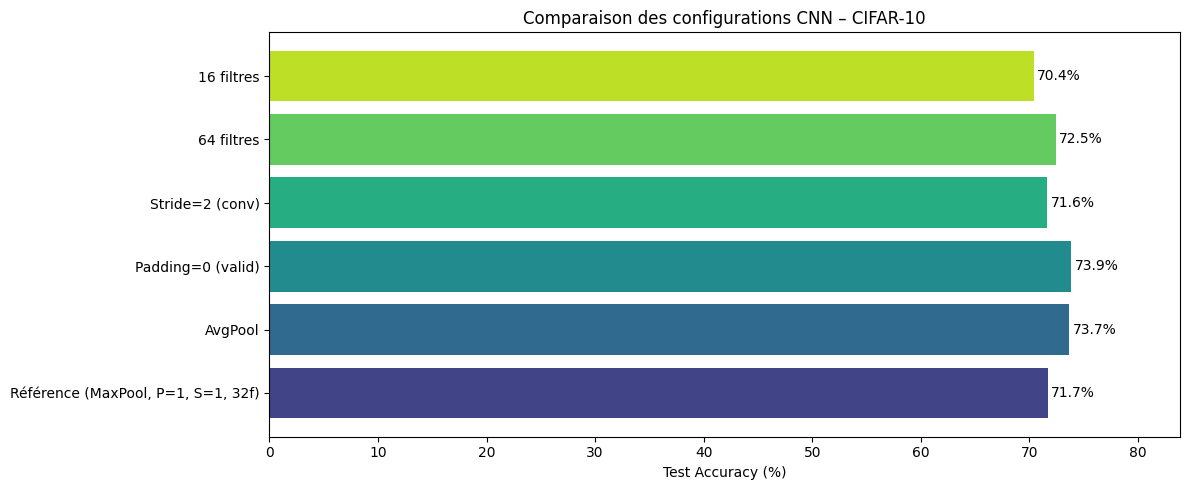

In [19]:
import pandas as pd
df_results = pd.DataFrame(results_exp)
print("\n" + "="*60)
print("TABLEAU COMPARATIF DES CONFIGURATIONS")
print("="*60)
print(df_results.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
configs = df_results['Config'].tolist()
test_accs = [float(v) if v != 'N/A' else 0 for v in df_results['Test Acc']]
bars = ax.barh(configs, test_accs, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(configs))))
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Comparaison des configurations CNN – CIFAR-10')
for bar, acc in zip(bars, test_accs):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontsize=10)
ax.set_xlim(0, max(test_accs) + 10)
plt.tight_layout()
plt.savefig('comparaison_configs.png', dpi=120)
plt.show()

Présence / Absence de convolution 1×1 : Expérience : effet de la convolution 1×1

In [20]:
print("Expérience – Convolution 1×1 : présente vs absente")
print("=" * 55)

results_1x1 = {}

for use_1x1, label in [(True, 'Avec conv 1×1'), (False, 'Sans conv 1×1')]:
    model_1x1 = CNN_Improved(use_conv1x1=use_1x1).to(device)
    n_p = sum(p.numel() for p in model_1x1.parameters() if p.requires_grad)
    optimizer_1x1 = optim.Adam(model_1x1.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler_1x1 = optim.lr_scheduler.CosineAnnealingLR(optimizer_1x1, T_max=15)
    h_1x1 = {'val_acc': []}
    for ep in range(15):
        train_epoch(model_1x1, train_loader, optimizer_1x1, criterion)
        _, va = evaluate(model_1x1, val_loader, criterion)
        scheduler_1x1.step()
        h_1x1['val_acc'].append(va)
    _, test_acc_1x1 = evaluate(model_1x1, test_loader, criterion)
    results_1x1[label] = h_1x1['val_acc']
    print(f"  {label} | Params={n_p:,} | Test Acc={test_acc_1x1*100:.2f}%")


Expérience – Convolution 1×1 : présente vs absente
  Avec conv 1×1 | Params=2,160,058 | Test Acc=71.14%
  Sans conv 1×1 | Params=2,168,746 | Test Acc=73.40%


Courbes

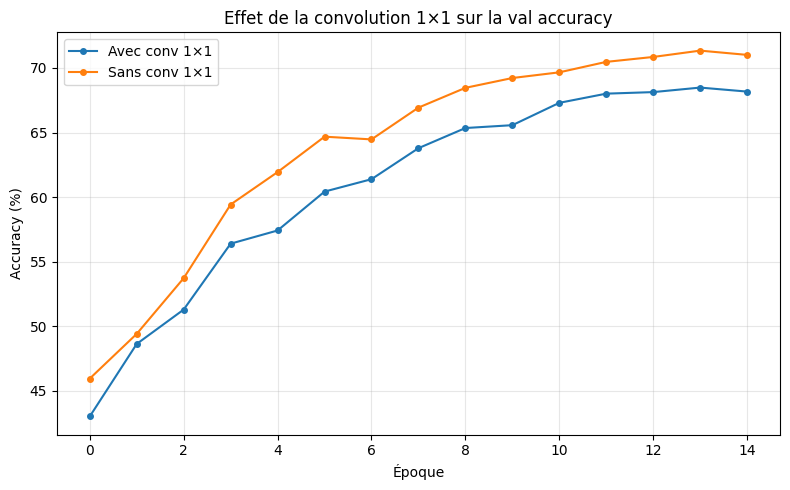

In [21]:
plt.figure(figsize=(8, 5))
for label, vals in results_1x1.items():
    plt.plot([v*100 for v in vals], marker='o', ms=4, label=label)
plt.title('Effet de la convolution 1×1 sur la val accuracy')
plt.xlabel('Époque')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp_conv1x1.png', dpi=120)
plt.show()

Évaluation finale et métriques (MLP vs CNN) : Sur l'ensemble de test


In [22]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            preds = model(X).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y.numpy())
    return np.array(all_labels), np.array(all_preds)

print("\n" + "="*60)
print("RÉSULTATS FINAUX SUR TEST SET")
print("="*60)

for model_name, model in [('MLP', mlp_model), ('CNN Amélioré', cnn_improved)]:
    y_true, y_pred = get_predictions(model, test_loader)
    acc = (y_true == y_pred).mean() * 100
    print(f"\n{'-'*50}")
    print(f"Modèle : {model_name}")
    print(f"Test Accuracy : {acc:.2f}%")
    print(classification_report(y_true, y_pred,
                                target_names=CLASSES, digits=3))


RÉSULTATS FINAUX SUR TEST SET

--------------------------------------------------
Modèle : MLP
Test Accuracy : 50.07%
              precision    recall  f1-score   support

       avion      0.569     0.616     0.592      1000
  automobile      0.583     0.621     0.601      1000
      oiseau      0.473     0.290     0.360      1000
        chat      0.329     0.408     0.364      1000
        cerf      0.530     0.244     0.334      1000
       chien      0.467     0.329     0.386      1000
  grenouille      0.501     0.569     0.533      1000
      cheval      0.520     0.626     0.568      1000
      bateau      0.609     0.673     0.639      1000
      camion      0.454     0.631     0.528      1000

    accuracy                          0.501     10000
   macro avg      0.504     0.501     0.491     10000
weighted avg      0.504     0.501     0.491     10000


--------------------------------------------------
Modèle : CNN Amélioré
Test Accuracy : 73.58%
              precision  

Matrices de confusion côte à côte


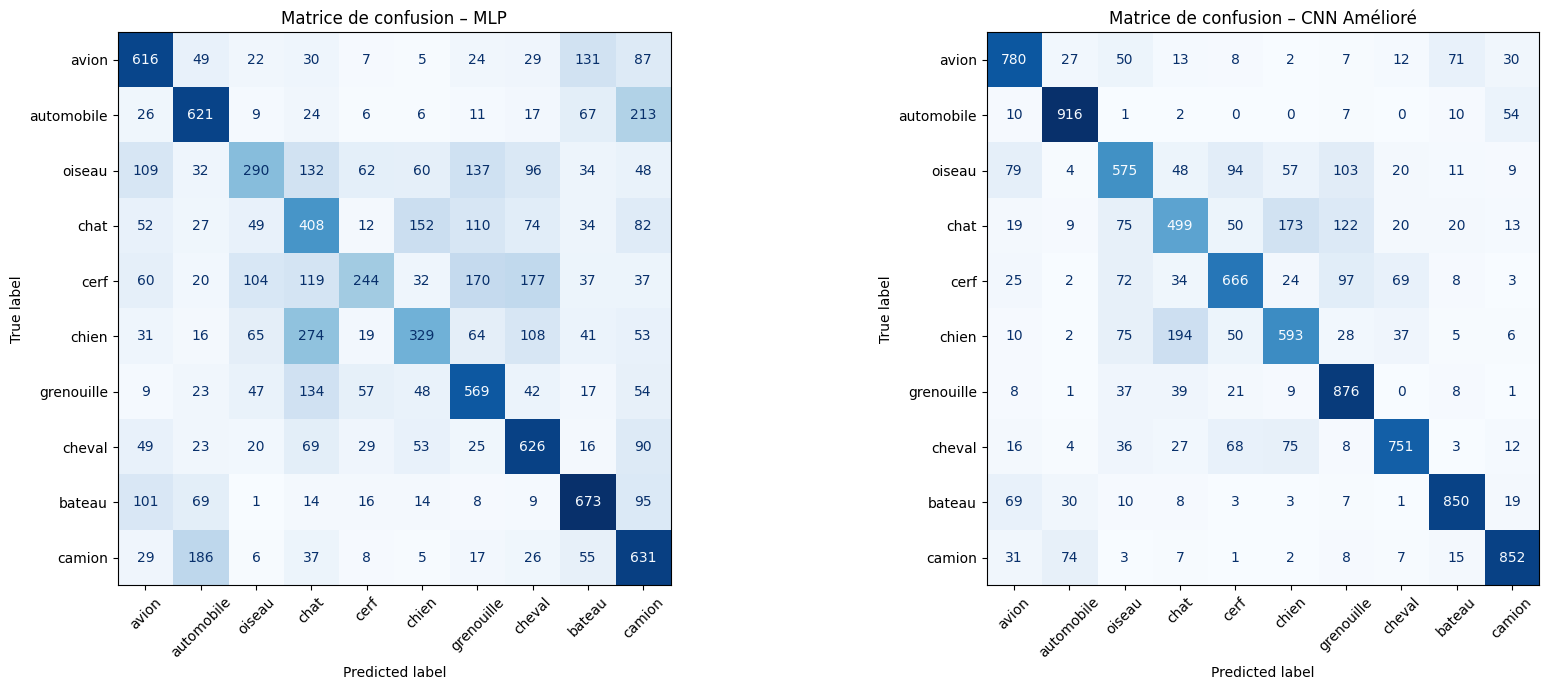

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, model_name, model in zip(axes,
                                  ['MLP', 'CNN Amélioré'],
                                  [mlp_model, cnn_improved]):
    y_true, y_pred = get_predictions(model, test_loader)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(f'Matrice de confusion – {model_name}', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120)
plt.show()

Visualisation des cartes de caractéristiques (feature maps)

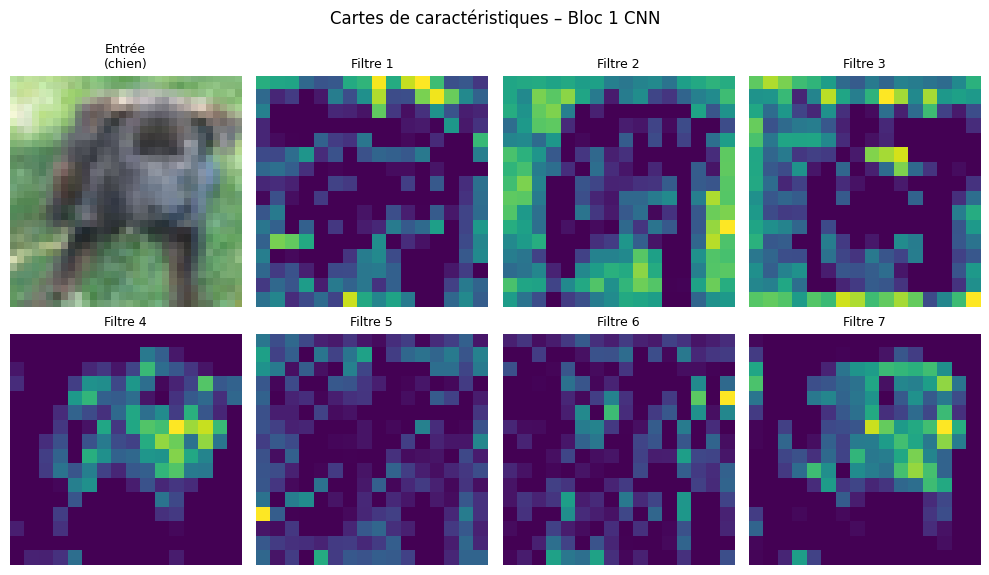

Forme des cartes de caractéristiques : torch.Size([32, 16, 16]) (C×H×W)


In [24]:
def visualize_feature_maps(model, dataset, layer_name='block1', n_img=1, n_filters=8):
    """
    Extrait et visualise les cartes de caractéristiques après le premier bloc convolutionnel.
    """
    model.eval()
    # Sélection d'une image
    img, label = dataset[np.random.randint(len(dataset))]
    img_batch = img.unsqueeze(0).to(device)

    # Hook pour capturer la sortie
    activations = {}
    def hook_fn(module, input, output):
        activations['feature_map'] = output.detach().cpu()

    # On attache le hook au premier bloc
    hook = model.block1.register_forward_hook(hook_fn)
    with torch.no_grad():
        _ = model(img_batch)
    hook.remove()

    fmaps = activations['feature_map'][0]  # (C, H, W)
    n_show = min(n_filters, fmaps.shape[0])

    # Affichage
    fig, axes = plt.subplots(2, n_show // 2 + n_show % 2, figsize=(2.5 * (n_show//2 + n_show%2), 6))
    axes = axes.flatten()

    # Image originale dénormalisée
    mean_t = torch.tensor(CIFAR_MEAN).view(3,1,1)
    std_t  = torch.tensor(CIFAR_STD).view(3,1,1)
    img_disp = (img * std_t + mean_t).permute(1, 2, 0).numpy().clip(0, 1)

    for i, ax in enumerate(axes):
        if i == 0:
            ax.imshow(img_disp)
            ax.set_title(f'Entrée\n({CLASSES[label]})', fontsize=9)
        elif i <= n_show:
            fm = fmaps[i-1].numpy()
            ax.imshow(fm, cmap='viridis')
            ax.set_title(f'Filtre {i}', fontsize=9)
        ax.axis('off')

    plt.suptitle('Cartes de caractéristiques – Bloc 1 CNN', fontsize=12)
    plt.tight_layout()
    plt.savefig('feature_maps.png', dpi=120)
    plt.show()
    print(f"Forme des cartes de caractéristiques : {fmaps.shape} (C×H×W)")


visualize_feature_maps(cnn_improved, test_set, n_filters=8)

Visualisation des filtres appris (noyaux de convolution)

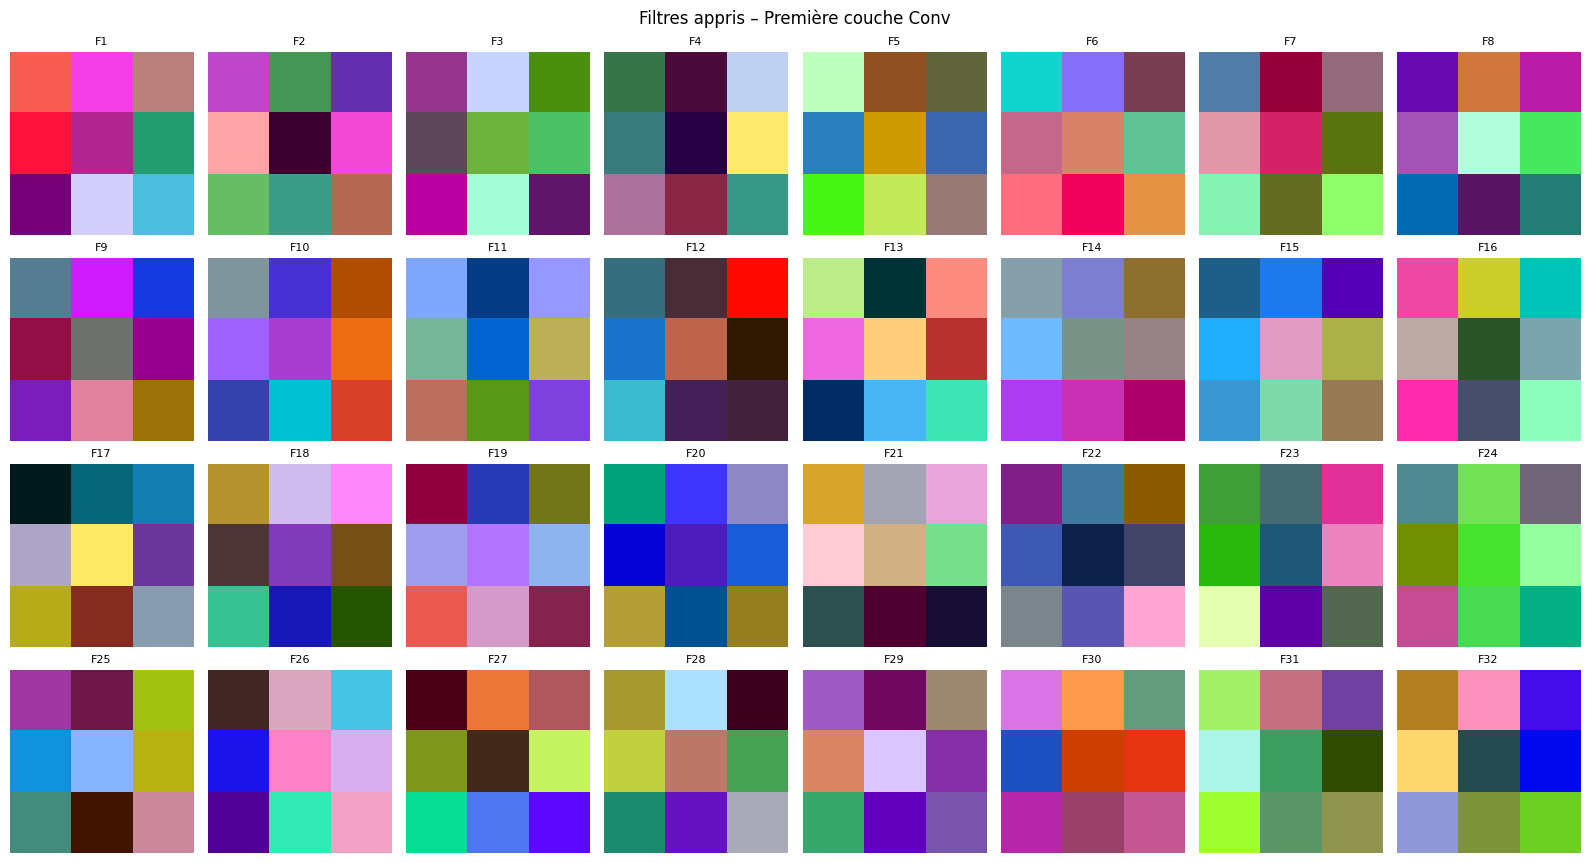

In [25]:
def visualize_filters(model, n_filters=16):
    """
    Visualise les filtres de la première couche de convolution.
    """
    # Récupération du premier Conv2d
    first_conv = None
    for m in model.modules():
        if isinstance(m, nn.Conv2d):
            first_conv = m
            break

    if first_conv is None:
        print("Aucune couche Conv2d trouvée.")
        return

    weights = first_conv.weight.data.cpu()  # (out_ch, in_ch, kH, kW)
    n_show = min(n_filters, weights.shape[0])
    ncols = 8
    nrows = (n_show + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2.2*nrows))
    axes = np.array(axes).flatten()

    for i in range(n_show):
        w = weights[i]  # (in_ch, kH, kW)
        if w.shape[0] == 3:  # RGB
            w = w.permute(1, 2, 0).numpy()
            w = (w - w.min()) / (w.max() - w.min() + 1e-8)
            axes[i].imshow(w)
        else:
            w_gray = w[0].numpy()
            axes[i].imshow(w_gray, cmap='gray')
        axes[i].set_title(f'F{i+1}', fontsize=8)
        axes[i].axis('off')

    for j in range(n_show, len(axes)):
        axes[j].axis('off')

    plt.suptitle('Filtres appris – Première couche Conv', fontsize=12)
    plt.tight_layout()
    plt.savefig('filters.png', dpi=120)
    plt.show()


visualize_filters(cnn_improved, n_filters=32)

Tableau récapitulatif final

In [26]:
print("\n" + "="*65)
print("COMPARAISON FINALE : MLP vs CNN sur CIFAR-10")
print("="*65)

n_params_mlp_val = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
n_params_cnn_val = sum(p.numel() for p in cnn_improved.parameters() if p.requires_grad)

y_true_mlp, y_pred_mlp = get_predictions(mlp_model, test_loader)
y_true_cnn, y_pred_cnn = get_predictions(cnn_improved, test_loader)

from sklearn.metrics import accuracy_score, f1_score

comparison = {
    'Modèle':        ['MLP',                   'CNN Amélioré'],
    'Paramètres':    [f'{n_params_mlp_val:,}',  f'{n_params_cnn_val:,}'],
    'Test Accuracy': [f'{accuracy_score(y_true_mlp, y_pred_mlp)*100:.2f}%',
                      f'{accuracy_score(y_true_cnn, y_pred_cnn)*100:.2f}%'],
    'F1-macro':      [f'{f1_score(y_true_mlp, y_pred_mlp, average="macro")*100:.2f}%',
                      f'{f1_score(y_true_cnn, y_pred_cnn, average="macro")*100:.2f}%'],
    'Structure spatiale': ['Non (flatten)', 'Oui (convolutions)'],
    'Invariance translation': ['Non', 'Oui (partage des poids)'],
}

df_comp = pd.DataFrame(comparison)
print(df_comp.to_string(index=False))


COMPARAISON FINALE : MLP vs CNN sur CIFAR-10
      Modèle Paramètres Test Accuracy F1-macro Structure spatiale  Invariance translation
         MLP  1,738,890        50.07%   49.06%      Non (flatten)                     Non
CNN Amélioré  2,160,058        73.58%   73.26% Oui (convolutions) Oui (partage des poids)


Graphique de comparaison MLP vs CNN sur les courbes d'entraînement

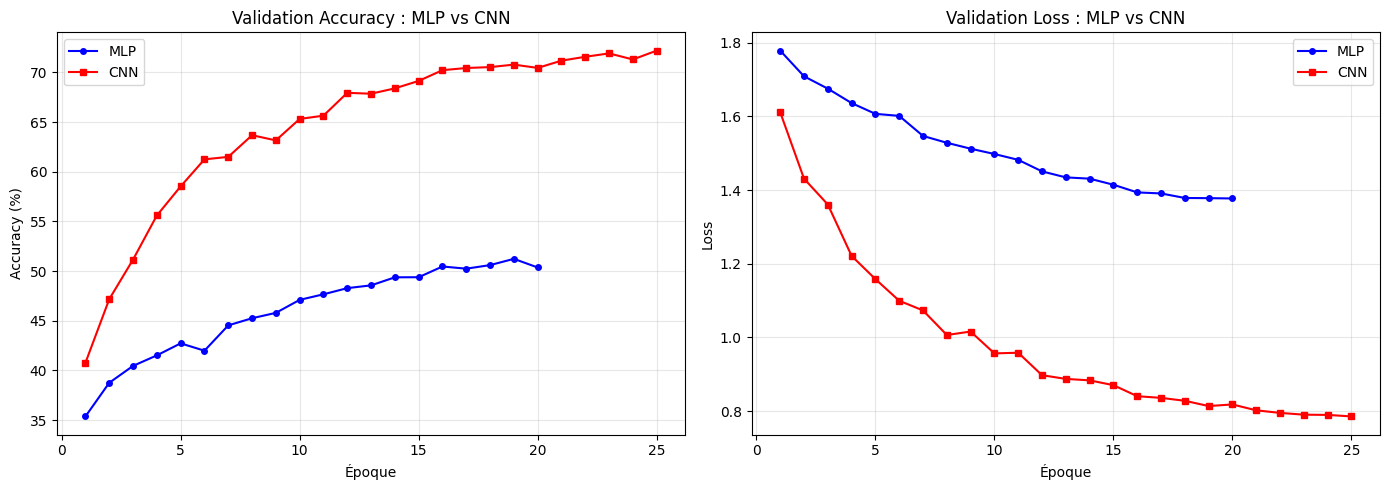

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_mlp = range(1, len(history_mlp['val_acc']) + 1)
epochs_cnn = range(1, len(history_cnn['val_acc']) + 1)

axes[0].plot(epochs_mlp, [a*100 for a in history_mlp['val_acc']],
             'b-o', ms=4, label='MLP')
axes[0].plot(epochs_cnn, [a*100 for a in history_cnn['val_acc']],
             'r-s', ms=4, label='CNN')
axes[0].set_title('Validation Accuracy : MLP vs CNN')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_mlp, history_mlp['val_loss'], 'b-o', ms=4, label='MLP')
axes[1].plot(epochs_cnn, history_cnn['val_loss'],  'r-s', ms=4, label='CNN')
axes[1].set_title('Validation Loss : MLP vs CNN')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_vs_cnn.png', dpi=120)
plt.show()

Sauvegarde et rechargement des meilleurs modèles

In [28]:
# Sauvegarde complète
torch.save({
    'model_state_dict': cnn_improved.state_dict(),
    'architecture': 'CNN_Improved',
    'n_params': n_params_cnn_val,
    'test_accuracy': accuracy_score(y_true_cnn, y_pred_cnn)
}, 'cnn_checkpoint.pth')

# Rechargement et vérification
checkpoint = torch.load('cnn_checkpoint.pth', map_location=device)
cnn_reloaded = CNN_Improved().to(device)
cnn_reloaded.load_state_dict(checkpoint['model_state_dict'])
cnn_reloaded.eval()

_, acc_reload = evaluate(cnn_reloaded, test_loader, nn.CrossEntropyLoss())
print(f"Modèle rechargé – Test Accuracy : {acc_reload*100:.2f}%")
print(f"Architecture : {checkpoint['architecture']}")
print(f"Paramètres   : {checkpoint['n_params']:,}")
print("Rechargement vérifié avec succès ✓")

Modèle rechargé – Test Accuracy : 73.58%
Architecture : CNN_Improved
Paramètres   : 2,160,058
Rechargement vérifié avec succès ✓


# 15. Question de synthèse – Partie II Problématique

Pourquoi un CNN est-il plus pertinent qu'un MLP pour une tâche de classification d'images sur un dataset réel, et comment les choix de padding, stride, pooling et profondeur influencent-ils les performances du modèle ?

**15.1Supériorité du CNN sur le MLP
Argument dimensionnel**

Dans un MLP, chaque pixel est connecté à tous les neurones de la couche suivante. Pour une image CIFAR-10 de taille 32×32×3, soit 3 072 pixels, une couche cachée de 512 neurones nécessite :

3072×512=1572864

poids dès la première couche.

En plus de ce grand nombre de paramètres, le MLP traite l'image comme un simple vecteur et ne tient pas compte de l'organisation spatiale des pixels.

À l'inverse, un CNN exploite directement la structure de l'image grâce aux opérations de convolution. Il peut ainsi apprendre des caractéristiques pertinentes avec un nombre de paramètres plus réduit.

Trois propriétés fondamentales des CNN

**1. Localité**

Chaque filtre de convolution analyse uniquement une petite région de l'image.

Par exemple, un noyau 3×3 observe 9 pixels voisins à la fois et permet de détecter des informations locales telles que :

les bords ;
les coins ;
les textures.

Cette approche est adaptée aux images car les pixels proches sont généralement corrélés.

**2. Partage des poids**

Un même filtre est appliqué sur toute l'image.

Ainsi, un filtre capable de détecter un bord vertical dans une zone de l'image pourra détecter ce même bord partout ailleurs.

Cette propriété réduit fortement le nombre de paramètres à apprendre.

**3. Hiérarchie des représentations**

Les couches successives apprennent des caractéristiques de plus en plus complexes :

premières couches : bords et contours ;
couches intermédiaires : formes simples ;
couches profondes : parties d'objets ;
dernières couches : objets complets.

Cette construction progressive permet une meilleure compréhension du contenu de l'image.

**15.2 Influence des choix architecturaux
Padding**

Le padding consiste à ajouter des pixels autour de l'image avant la convolution.

Padding = 0 (Valid)

La taille de l'image diminue après chaque convolution.

**Conséquences :**

réduction progressive des dimensions ;
perte d'informations situées près des bords.
Padding = 1 (Same)

Des pixels supplémentaires sont ajoutés autour de l'image.

**Conséquences :**

conservation des dimensions spatiales ;
meilleure exploitation des informations présentes aux frontières de l'image.

Pour des images de petite taille comme celles de CIFAR-10, cette approche est généralement préférable.

Stride

Le stride représente le déplacement du filtre lors de la convolution.

Stride = 1

Le filtre se déplace d'un pixel à la fois.

**Avantages :**

conservation maximale des détails ;
meilleure extraction des caractéristiques.
Stride = 2

Le filtre se déplace de deux pixels à chaque étape.

**Avantages :**

réduction rapide des dimensions ;
diminution du coût de calcul.

**Inconvénient :**

perte potentielle d'informations fines.
Pooling

Le pooling réduit la taille des cartes de caractéristiques.

Max Pooling

Conserve uniquement la valeur maximale de chaque région.

**Avantages :**

mise en évidence des caractéristiques les plus importantes ;
meilleure robustesse aux petites translations.
Average Pooling

Calcule la moyenne des valeurs présentes dans la région.

**Avantages :**

conservation d'une information plus globale ;
réduction plus douce des données.

Le Max Pooling est généralement privilégié dans les tâches de classification d'images.

Nombre de filtres

Le nombre de filtres détermine la quantité de caractéristiques pouvant être apprises.

Peu de filtres : capacité limitée.
Beaucoup de filtres : meilleure représentation des données.

Cependant, une augmentation excessive du nombre de filtres entraîne :

davantage de paramètres ;
un coût de calcul plus important ;
un risque accru de surapprentissage.
Convolutions 1×1

Les convolutions 1×1 agissent uniquement sur les canaux de l'image sans modifier sa résolution spatiale.

Elles permettent :

de réduire le nombre de canaux ;
de diminuer le nombre de paramètres ;
d'introduire de nouvelles transformations non linéaires.

Cette technique est fréquemment utilisée dans les architectures modernes.

**15.3 Limites des CNN Malgré leurs performances, les CNN présentent certaines limites.**

Sensibilité aux transformations importantes

Les CNN sont relativement robustes aux petites translations, mais restent sensibles aux transformations importantes telles que :

grandes rotations ;
changements d'échelle ;
déplacements importants.
Interprétabilité limitée

Il est possible de visualiser certaines cartes de caractéristiques, mais l'interprétation exacte des représentations apprises dans les couches profondes reste difficile.

Hypothèses spécifiques aux images

Les CNN reposent sur l'idée que les informations importantes sont locales et que les mêmes motifs peuvent apparaître à différents endroits.

Ces hypothèses sont adaptées aux images, mais peuvent être moins pertinentes pour d'autres types de données.

Choix des hyperparamètres

Les performances dépendent fortement du choix :

du nombre de couches ;
du nombre de filtres ;
du padding ;
du stride ;
du type de pooling.

La conception d'une architecture efficace nécessite donc plusieurs expérimentations.

**15.4 Conclusion**

Les CNN sont mieux adaptés que les MLP à la classification d'images car ils exploitent directement la structure spatiale des données.

Leur efficacité repose principalement sur :

la localité ;
le partage des poids ;
l'apprentissage hiérarchique des caractéristiques.

Les paramètres architecturaux tels que le padding, le stride, le pooling et le nombre de filtres influencent directement la qualité des représentations apprises et les performances finales du modèle. Le choix de ces paramètres constitue donc une étape essentielle dans la conception d'un réseau de neurones convolutif performant.